
# Experiment 3: Image Enhancement using histogram Equalization

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

array([[[ 72,  64, 174],
        [ 72,  64, 173],
        [ 72,  63, 173],
        ...,
        [129, 133, 210],
        [130, 133, 210],
        [121, 130, 205]],

       [[ 72,  63, 173],
        [ 72,  63, 173],
        [ 72,  63, 172],
        ...,
        [127, 134, 207],
        [129, 135, 206],
        [123, 129, 202]],

       [[ 72,  61, 171],
        [ 72,  61, 171],
        [ 72,  60, 170],
        ...,
        [118, 132, 203],
        [120, 132, 203],
        [121, 130, 201]],

       ...,

       [[ 60,  15,  91],
        [ 60,  15,  91],
        [ 60,  17,  92],
        ...,
        [ 59,  27, 119],
        [ 60,  27, 119],
        [ 62,  33, 121]],

       [[ 60,  18,  95],
        [ 60,  18,  95],
        [ 60,  19,  95],
        ...,
        [ 62,  32, 123],
        [ 61,  32, 123],
        [ 63,  36, 125]],

       [[ 60,  22,  99],
        [ 60,  22,  99],
        [ 60,  22,  99],
        ...,
        [ 65,  41, 125],
        [ 63,  40, 124],
        [ 63,  38, 125]]], dtype=uint8)
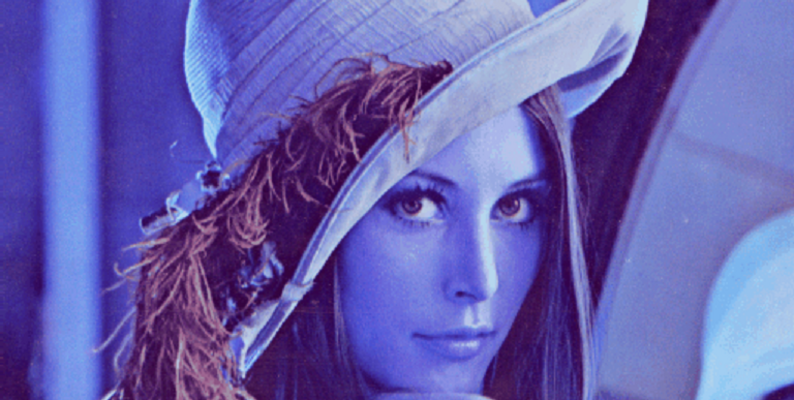

In [ ]:
image=cv2.imread("/content/drive/MyDrive/Colab Notebooks/IPCV/dataset-cover.png")
image

array([[ 98,  98,  97, ..., 156, 156, 151],
       [ 97,  97,  97, ..., 155, 156, 150],
       [ 95,  95,  94, ..., 152, 152, 150],
       ...,
       [ 43,  43,  44, ...,  58,  58,  63],
       [ 46,  46,  46, ...,  63,  63,  66],
       [ 49,  49,  49, ...,  69,  68,  67]], dtype=uint8)
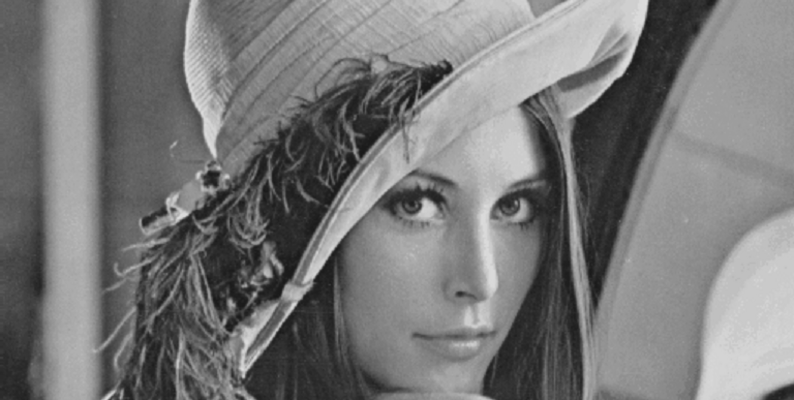

In [ ]:
gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
gray

2. Initialize an array hist with zeros of size 256
3. for each pixel value h in img:
• Increment hist[h] by 1

In [ ]:
hist = [0] * 256
rows, cols, _ = image.shape
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
for i in range(rows):
    for j in range(cols):
        pixel = gray[i][j]
        hist[pixel] += 1

4. Normalize hist by dividing each value by total number of pixels

In [ ]:
totalpixels = rows * cols
hist_normalize = [h / totalpixels for h in hist]

5. Compute cumulative sum of hist to obtain cdf

In [ ]:
cdf = [0] * 256
cdf[0] = hist_normalize[0]

for i in range(1, 256):
    cdf[i] = cdf[i-1] + hist_normalize[i]

6. for each gray level i from 0 to 255:
• new value[i] = round(255 * cdf[i])

In [ ]:
new_values = [round(255 * cdf[i]) for i in range(256)]

7. for each pixel h in img:
• Replace h with new value[h]

In [ ]:
equalized_img = np.zeros((rows, cols), dtype=np.uint8) #unsigned integer range 0-255

for i in range(rows):
    for j in range(cols):
        equalized_img[i][j] = new_values[gray[i][j]]

8. Display the histogram equalized image

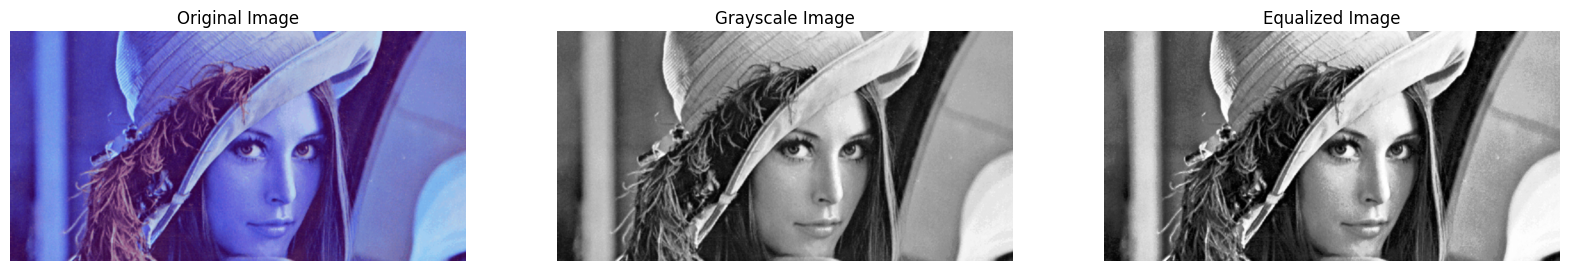

In [ ]:
plt.figure(figsize=(20, 10))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(image,cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Grayscale Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Equalized Image")
plt.imshow(equalized_img, cmap='gray')
plt.axis('off')

plt.show()

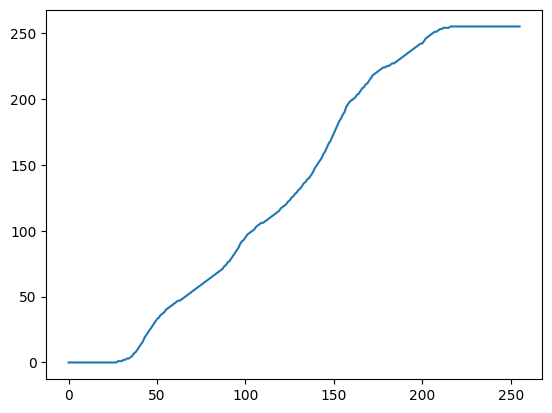

In [ ]:
plt.plot(new_values)

**The final output of this experiment is a histogram equalized image, which is an enhanced version of the original image with improved contrast due to the application of histogram equalization.**